# Deliberate overfitting diagnostic

This notebook trains on a tiny fixed split, then compares seen, held-out, and shuffled conditioning vectors. The goal is to verify memorization and conditioning sensitivity, not production generalization.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import random
import warnings
import numpy as np
import torch

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.artificial import generate_artificial_dataset
from conditional_node_field_graph_generator.extensions.demo.overfit_evaluation import (
    evaluate_overfit_generalization,
    plot_overfit_reconstructions,
    plot_overfit_summary,
)

PyTorch version: 2.13.0
CUDA available: False


## 1. Overfit parameters

In [2]:
RANDOM_SEED = 42
DATASET_SIZE = 6
N_ITERATIONS = 1
CYCLE_LENGTH = [3, 8]
NUM_CYCLES = 1
PATH_LENGTH = 2
NUM_RAYS = 3
RAY_LENGTH = 1
NODE_ALPHABET_SIZE = 8
EDGE_ALPHABET_SIZE = 3
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True

FIT_BATCH_SIZE = 1
MAXIMUM_EPOCHS = 300
TRAIN_ON_ALL_EXAMPLES = True
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 256
GENERALIZATION_HOLDOUT_FRACTION = 0.50
GENERALIZATION_SPLIT_SEED = 10
GENERALIZATION_SAMPLES_PER_GRAPH = 6
GENERALIZATION_USE_ILP_DECODER = True
OVERFIT_TARGETS = {
    'max_seen_error': 0.90,
    'min_heldout_gap': 0.20,
    'min_shuffled_gap': 0.20,
}

CYCLE_COUNT_TOKEN = '' if NUM_CYCLES == 1 else f'-nc{NUM_CYCLES}'
ITERATION_COUNT_TOKEN = '' if N_ITERATIONS == 1 else f'-ni{N_ITERATIONS}'
CYCLE_LENGTH_TOKEN = '-'.join(str(value) for value in CYCLE_LENGTH)
MODEL_NAME = (
    f'artificial-cycle-path-star-overfit-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH_TOKEN}{CYCLE_COUNT_TOKEN}{ITERATION_COUNT_TOKEN}'
    f'-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}-d{EMBEDDING_DIM}'
    f'-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## 2. Dataset and fixed train/held-out split

Saved artificial dataset config: artificial-cycle-path-star-n6-c3-8-p2-r3x1-na8-ea3.yaml
Fit graphs: 3 | held-out graphs: 3


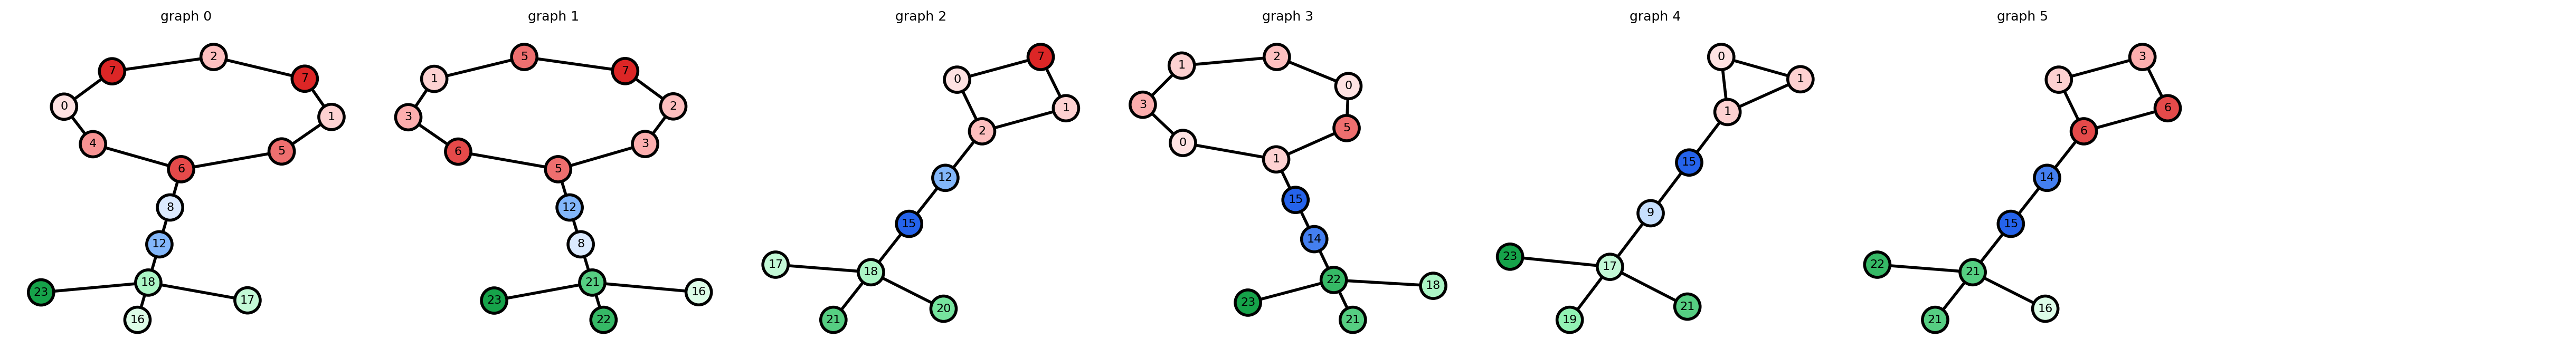

In [3]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    n_iterations=N_ITERATIONS,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
    save_config_dir=REPO_ROOT / 'notebooks' / 'configs' / 'artificial_datasets',
)

split_rng = np.random.default_rng(GENERALIZATION_SPLIT_SEED)
split_indices = split_rng.permutation(len(graphs))
n_holdout = max(1, int(round(GENERALIZATION_HOLDOUT_FRACTION * len(graphs))))
heldout_indices = split_indices[:n_holdout]
fit_indices = split_indices[n_holdout:]
fit_graphs = [graphs[int(index)] for index in fit_indices]
heldout_graphs = [graphs[int(index)] for index in heldout_indices]
print(f'Fit graphs: {len(fit_graphs)} | held-out graphs: {len(heldout_graphs)}')

_ = plot_artificial_graphs(
    graphs,
    n_cols=7,
    titles=[f'graph {idx}' for idx in range(len(graphs))],
    size=3.5,
)

## 3. Build and train the intentionally overparameterized model

Configured graph generator model_name=artificial-cycle-path-star-overfit-n6-c3-8-p2-r3x1-d256-b1-e300 model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
________________________________________________________________________________
Training target: model 'artificial-cycle-path-star-overfit-n6-c3-8-p2-r3x1-d256-b1-e300'. Saved model files will go to '/Users/f.costa/Code/NodeField/.artifacts/saved_generators'.
________________________________________________________________________________
Starting training on 3 synthetic graphs. Next, the generator will learn graph representations, prepare its training targets, and train the neural graph generator. This may take some time.
________________________________________________________________________________
Step 1 of 11 | Next: learn how to describe each complete graph with numeric features. Purpose: The generator will use this representation to understand each graph as a whole.
Step 1 of 11 | Done: Learned complete-graph 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 10/300 | ETA 0h 00m 46s | Next output ETA 0h 00m 02s (10 epochs):
  train total=   28.260 | node_field    4.0421 [14.3%] |        deg    1.7245 [6.1%] |      exist   0.27680 [1.0%] | node_count   0.00534 [<0.1%]
  val   total=   23.510 | node_field    3.9975 [17.0%] |        deg    1.8385 [7.8%] |      exist   0.26611 [1.1%] | node_count   0.00594 [<0.1%]
  train                 | node_label    3.4180 [12.1%] | edge_label    3.0948 [11.0%] |       edge    1.7659 [6.2%] | edge_count    13.151 [46.5%] | deg_edge_consistency   0.00031 [<0.1%]
  val                   | node_label    3.2156 [13.7%] | edge_label    3.1090 [13.2%] |       edge    1.8749 [8.0%] | edge_count    8.4242 [35.8%] | deg_edge_consistency   0.00231 [<0.1%]
  train                 |        aux   0.78157 [2.8%] | dominant=edge_count [46.5%]
  val                   |        aux   0.77587 [3.3%] | dominant=edge_count [35.8%]
epoch 10: sampling training progress graphs
epoch 10: appended training sample PDF page to /

`Trainer.fit` stopped: `max_epochs=300` reached.


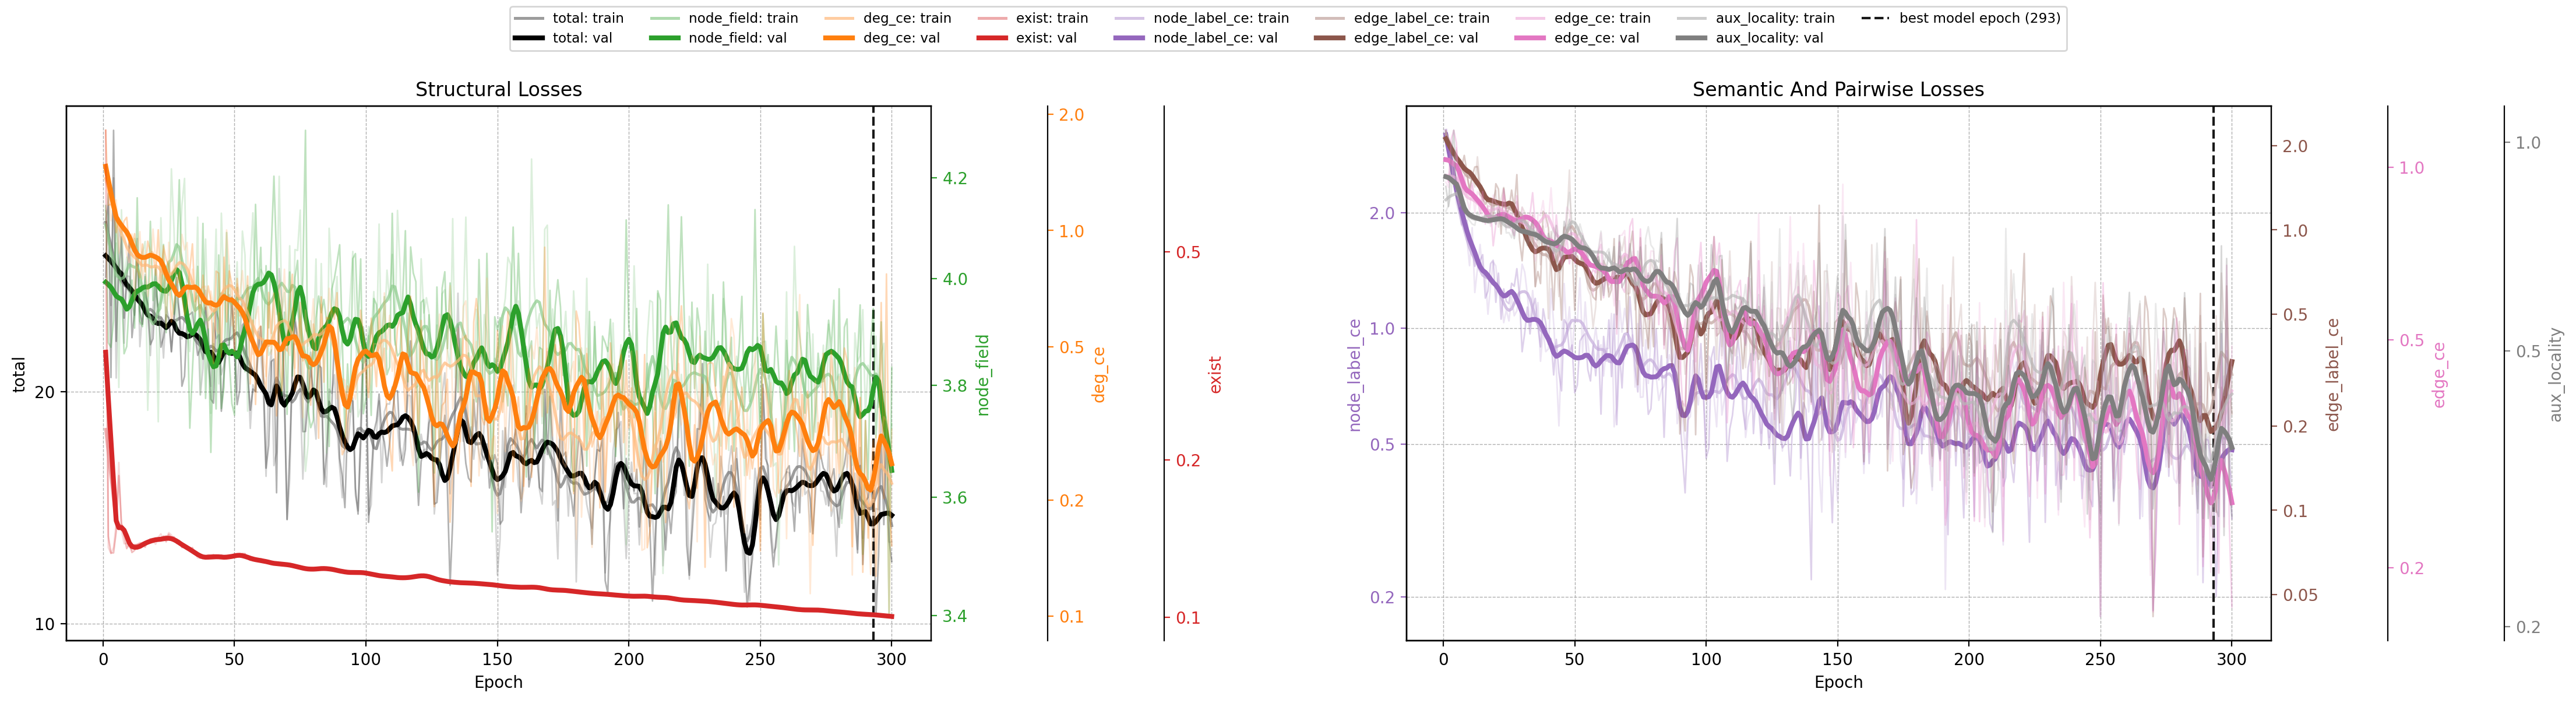

Done: the neural graph generator finished training. Time: 9m 43.2s.
________________________________________________________________________________
Training complete: The generator is ready to create graphs. Total time: 9m 44.4s.


In [4]:
NODE_FIELD_CONFIG = {
    'node_field_mode': 'recurrent_energy',
    'recurrent_hidden_dimension': None,
    'recurrent_training_steps': 2,
    'recurrent_detach_interval': 2,
    'recurrent_update_scale': 1.0,
    'recurrent_initial_state': 'zeros',
    'recurrent_state_normalization': True,
    'recurrent_corruption_schedule': 'constant',
    'recurrent_sigma_min': 0.1,
    'recurrent_sigma_max': 0.5,
    'recurrent_supervise_all_steps': True,
    'recurrent_loss_discount': 1.0,
}

graph_generator = build_graph_generator(
    **NODE_FIELD_CONFIG,
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=2,
    transformer_attention_head_count=8,
    transformer_dropout=0.0,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.0,
    cfg_condition_dropout_prob=0.0,
    learning_rate=5e-4,
    node_field_sigma=0.5,
    sampling_step_size=0.05,
    sampling_steps=50,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    train_on_all_examples=TRAIN_ON_ALL_EXAMPLES,
    enable_early_stopping=False,
    restore_best_checkpoint=False,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS

TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
graph_generator.fit(
    fit_graphs,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=10,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_fn=plot_artificial_graphs,
)

## 4. Conditional reconstruction scores

In [5]:
overfit_evaluation = evaluate_overfit_generalization(
    graph_generator,
    fit_graphs,
    heldout_graphs,
    samples_per_graph=GENERALIZATION_SAMPLES_PER_GRAPH,
    use_ilp_decoder=GENERALIZATION_USE_ILP_DECODER,
    targets=OVERFIT_TARGETS,
)

overfit_metrics = overfit_evaluation['overfit_metrics']
print('Overfit success:', overfit_metrics['overfit_success'])
print('Objective:', overfit_metrics['overfit_objective'])
print('Seen error:', overfit_metrics['seen_error'])
print('Held-out gap:', overfit_metrics['heldout_gap'])
print('Shuffled gap:', overfit_metrics['shuffled_gap'])

Evaluate conditional reconstruction on seen and held-out graphs.
Seen/train conditions: {'exact_rate_per_sample': 0.0, 'exact_rate_any_sample': 0.0, 'node_count_mae': 0.0, 'edge_count_mae': 0.05555555555555555, 'node_label_hist_l1': 0.611111111111111, 'degree_hist_l1': 0.5682539682539682, 'edge_label_hist_l1': 0.855026455026455}
Held-out conditions: {'exact_rate_per_sample': 0.0, 'exact_rate_any_sample': 0.0, 'node_count_mae': 0.0, 'edge_count_mae': 0.0, 'node_label_hist_l1': 1.3407271740605073, 'degree_hist_l1': 0.4611992945326279, 'edge_label_hist_l1': 1.2885632885632885}
Generalization gap (exact any-sample rate): 0.0
Decoding 18 conditioning vectors
Decoding 18 conditioning vectors
Shuffled seen/train conditions: {'exact_rate_per_sample': 0.0, 'exact_rate_any_sample': 0.0, 'node_count_mae': 0.0, 'edge_count_mae': 0.0, 'node_label_hist_l1': 1.3158730158730159, 'degree_hist_l1': 0.5253968253968254, 'edge_label_hist_l1': 0.8746031746031746}
Shuffled held-out conditions: {'exact_rate_p

## 5. Visual comparison

The summary compares errors and gaps. The graph panels show three generated reconstructions per condition type, with clear section labels and counters when there is more than one example.

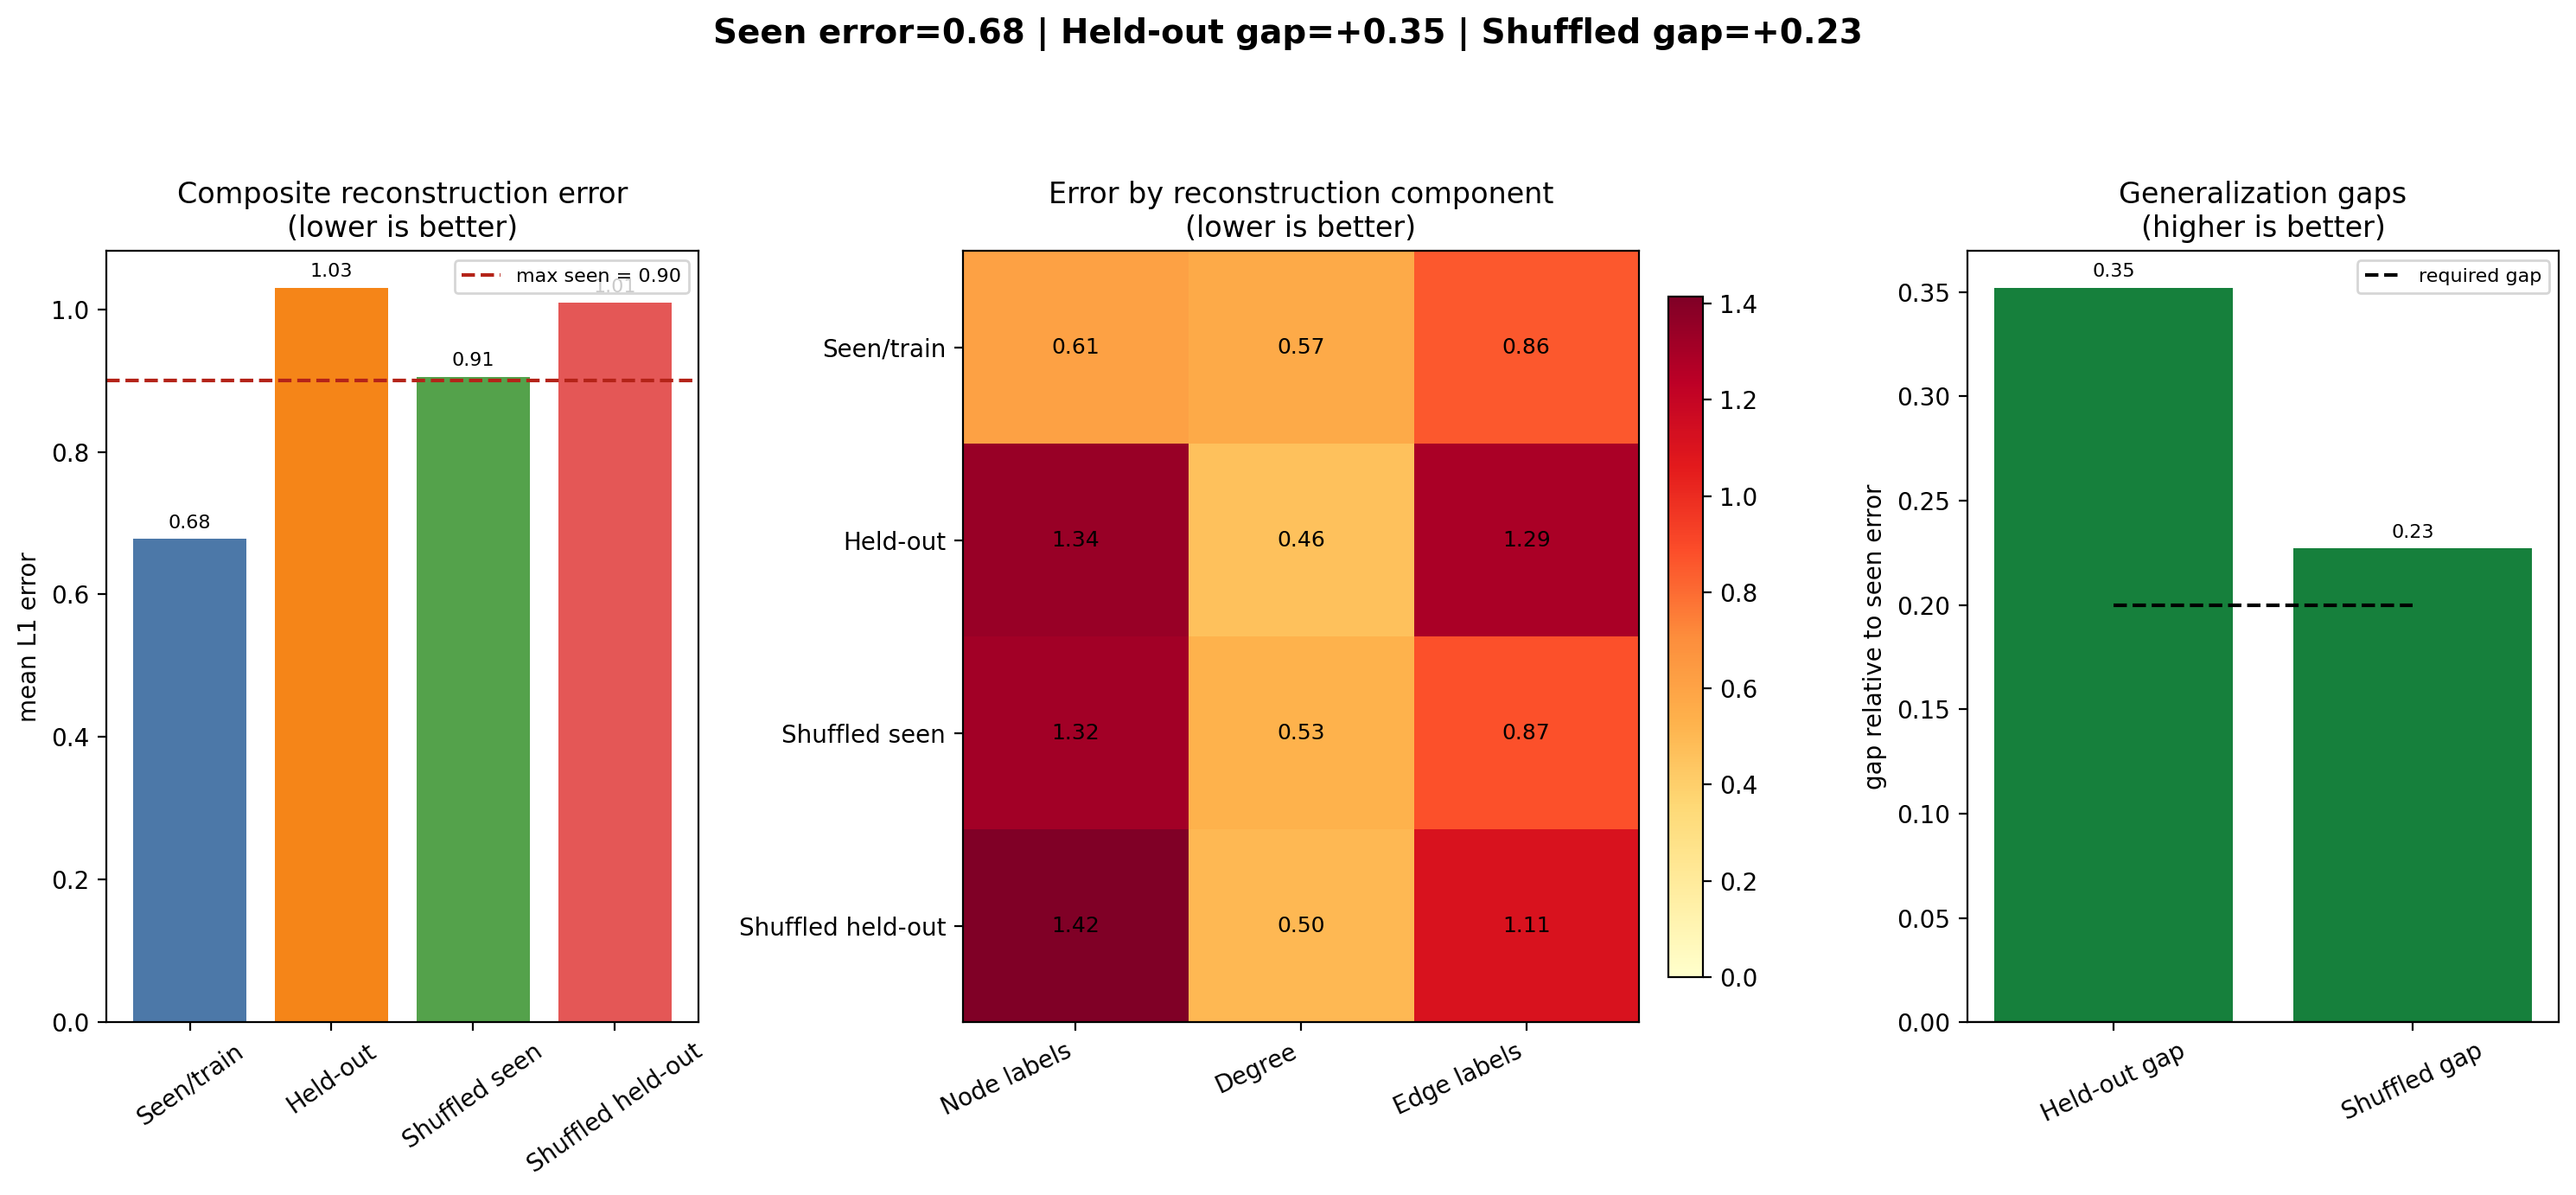

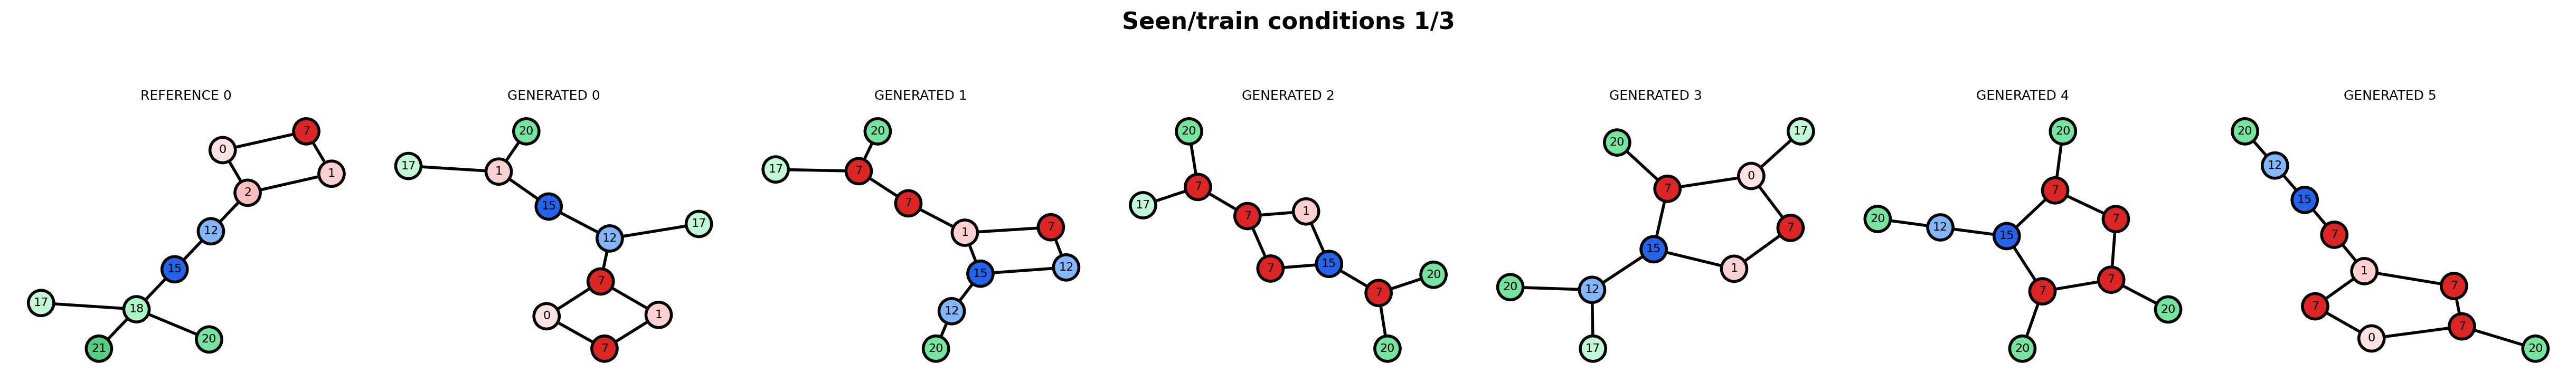

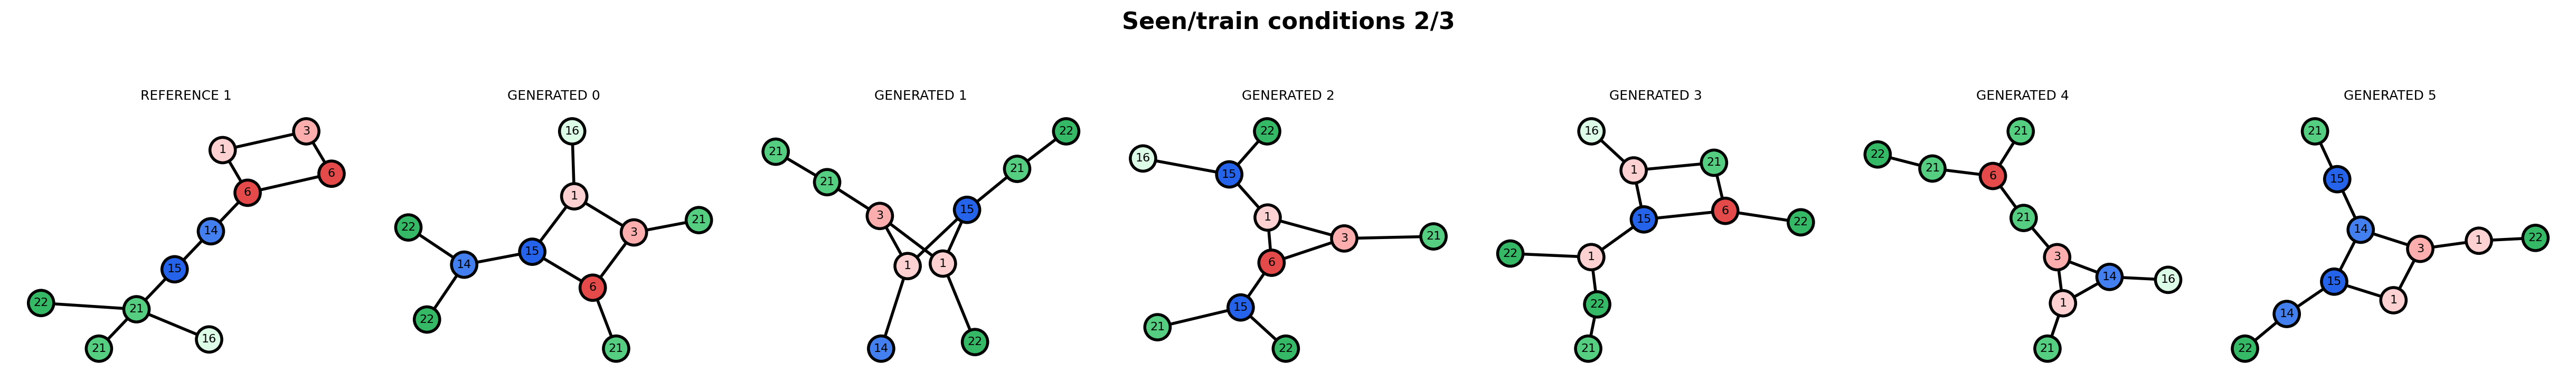

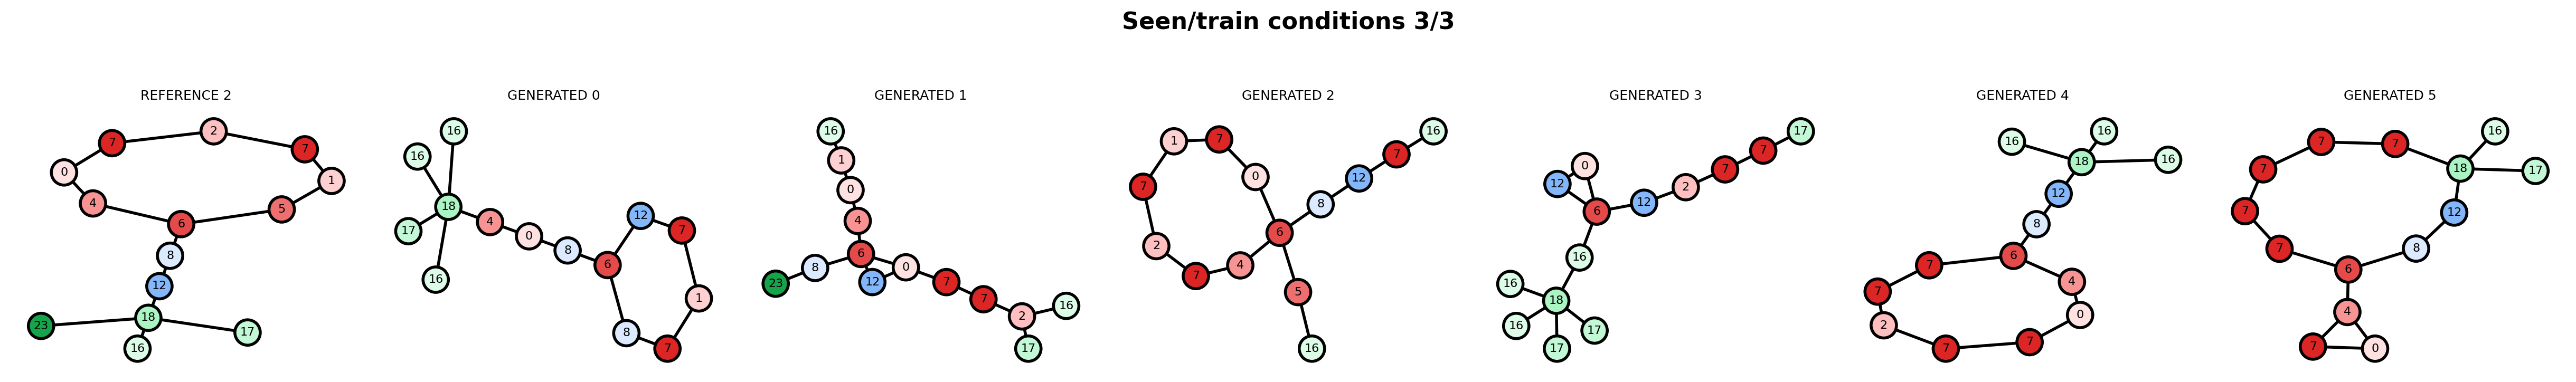

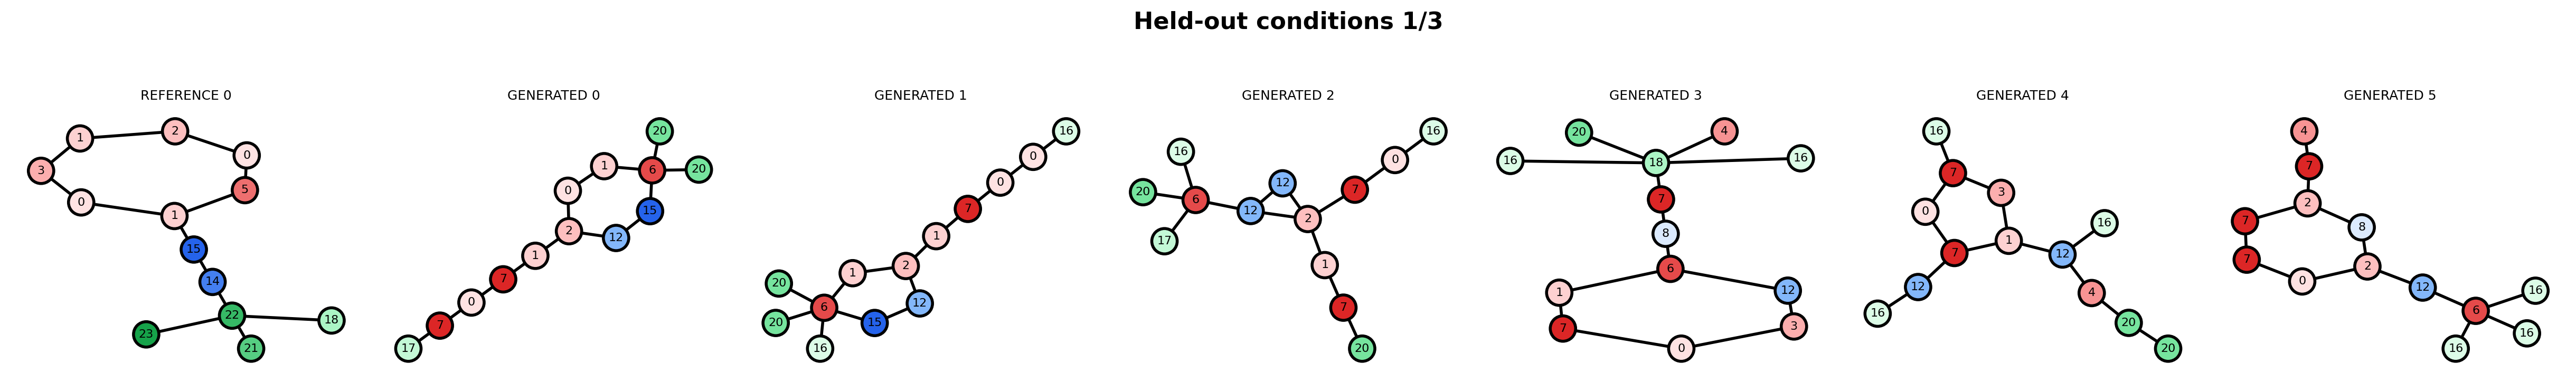

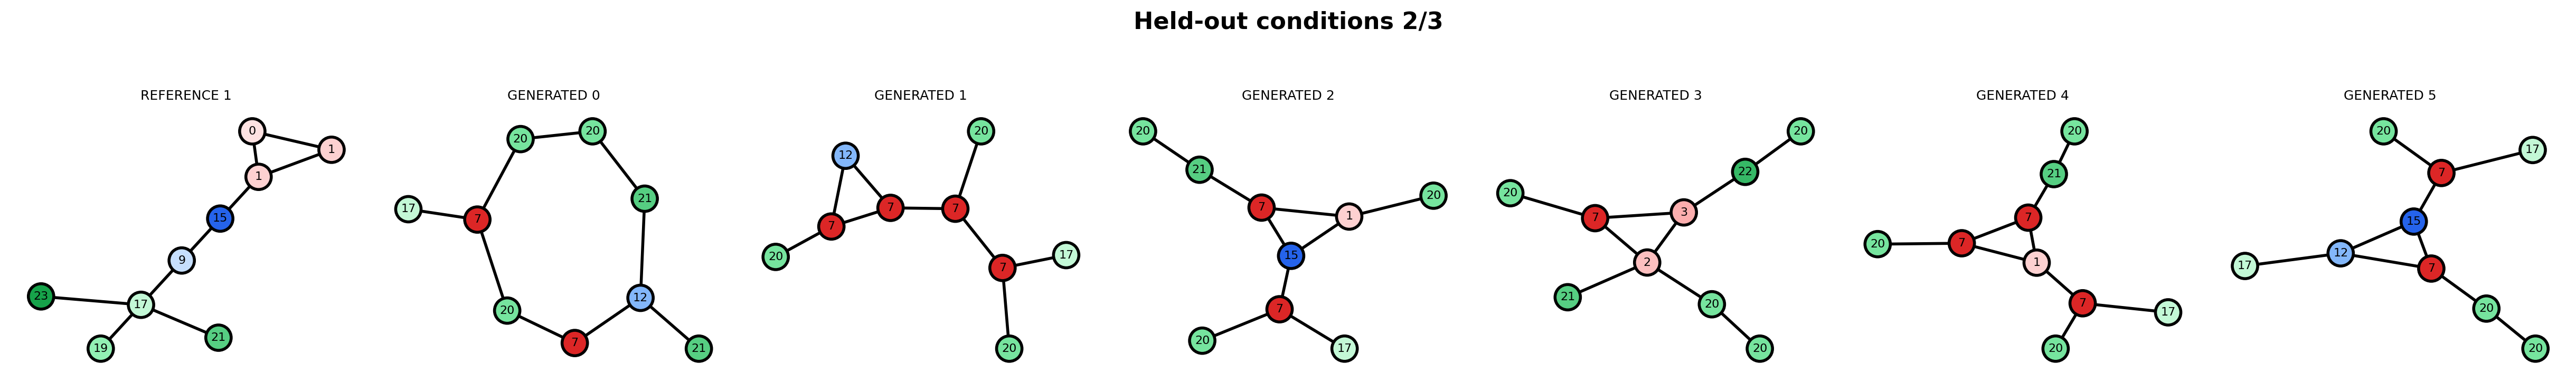

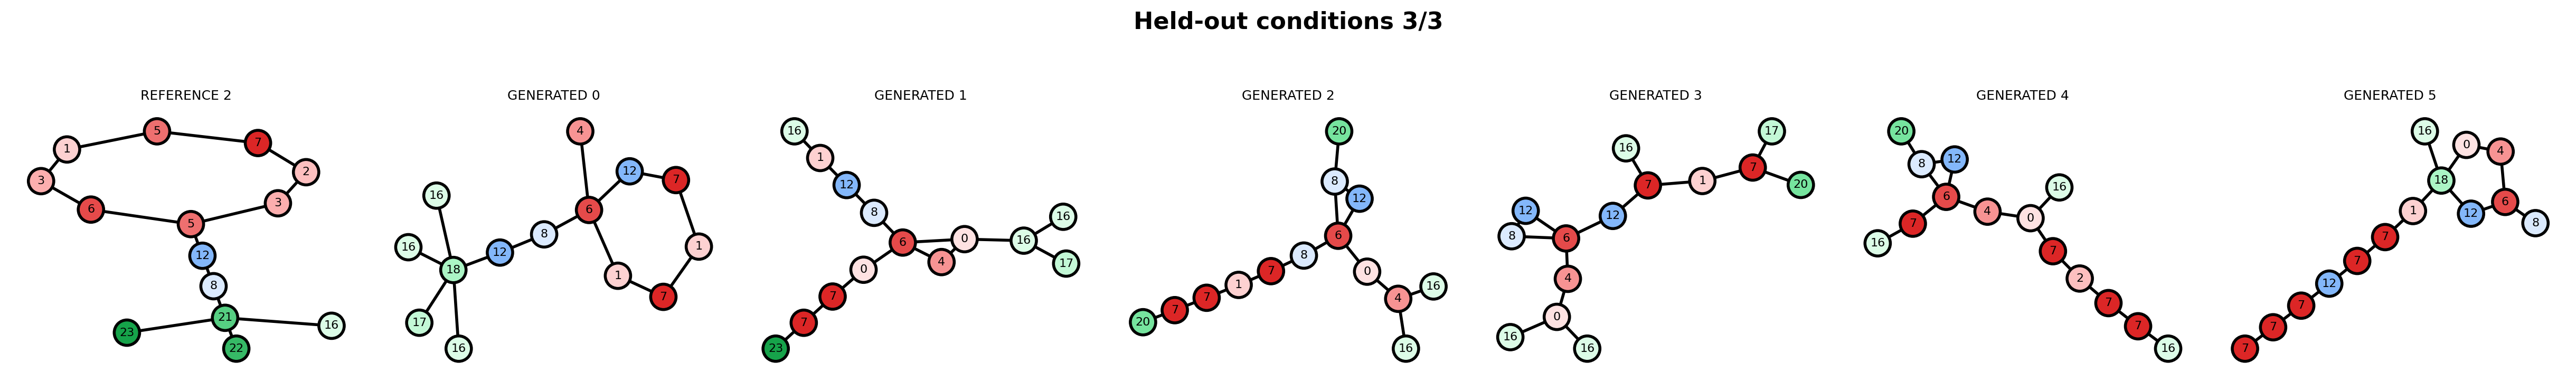

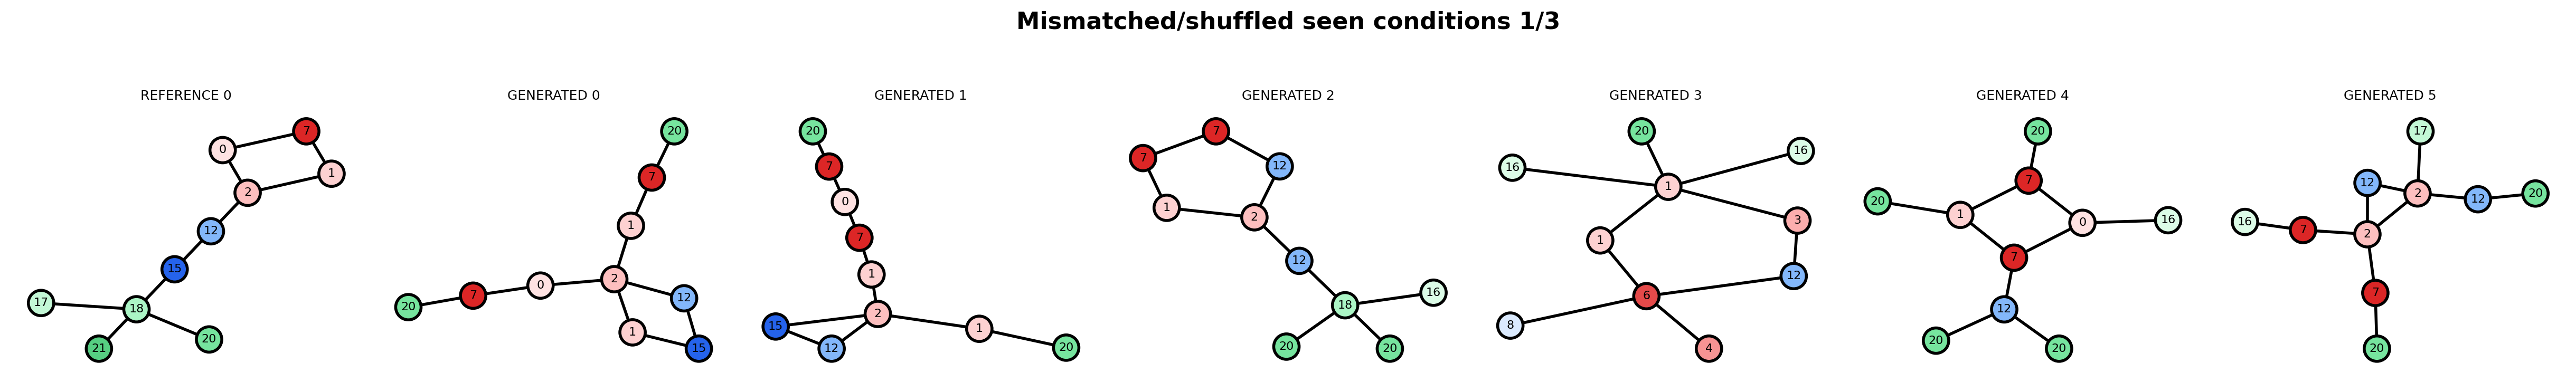

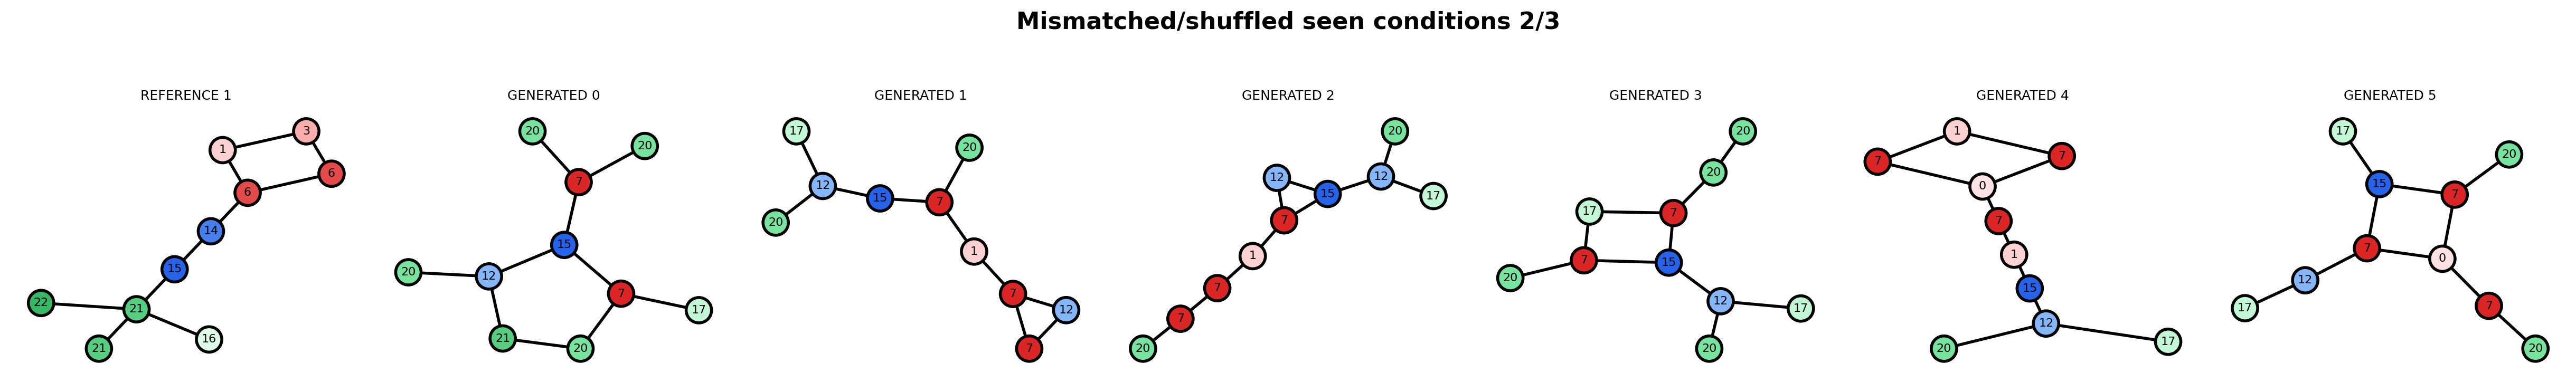

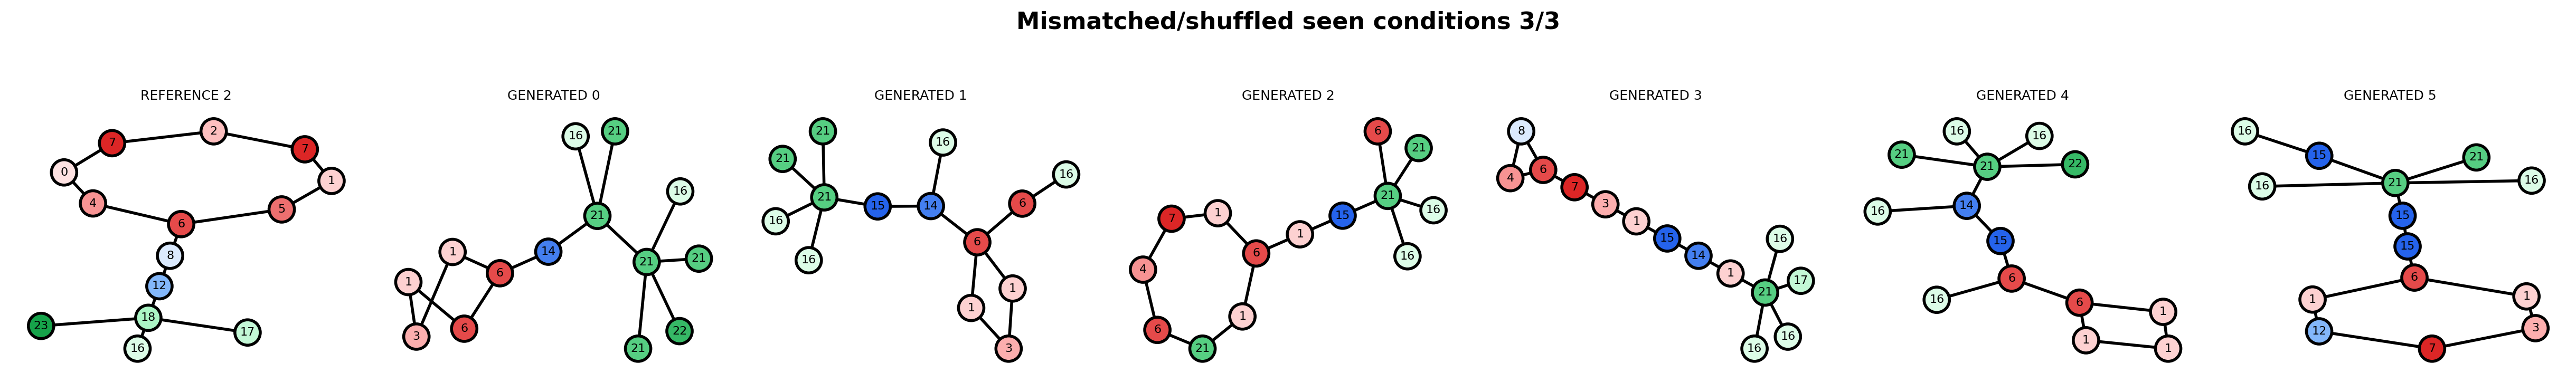

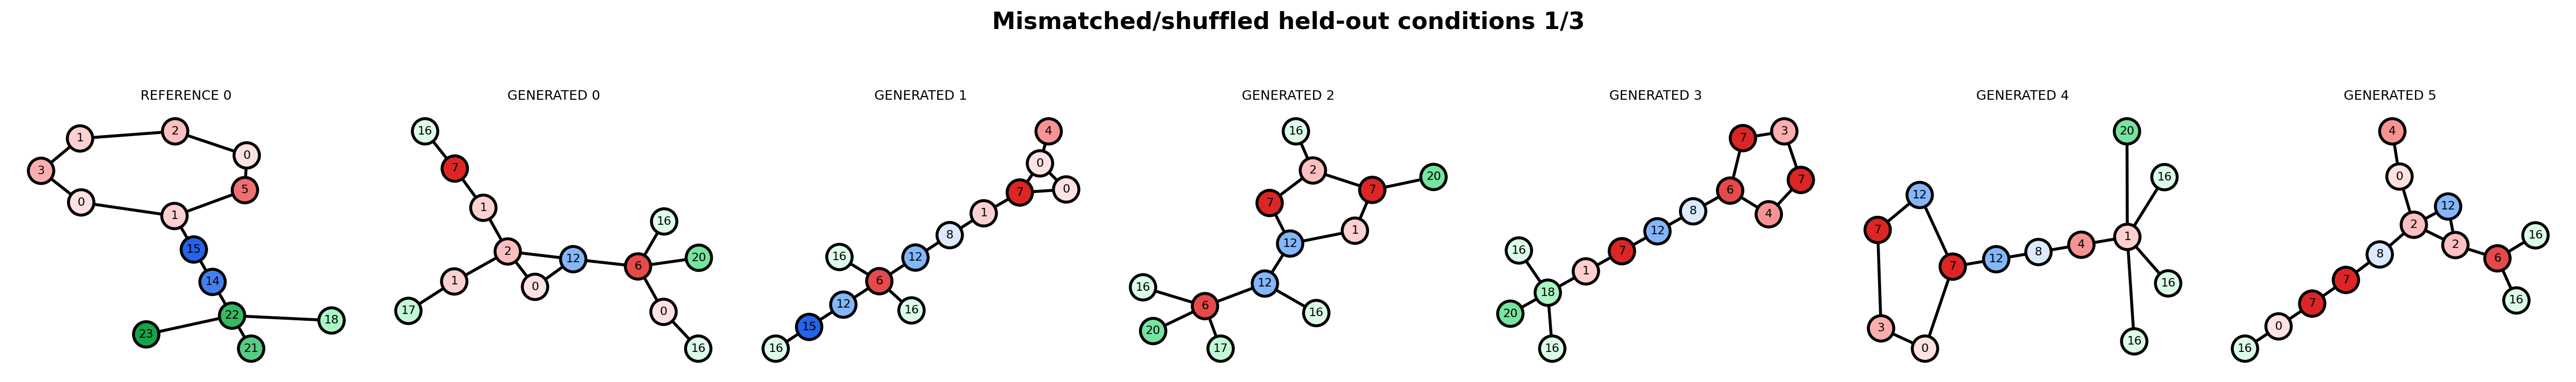

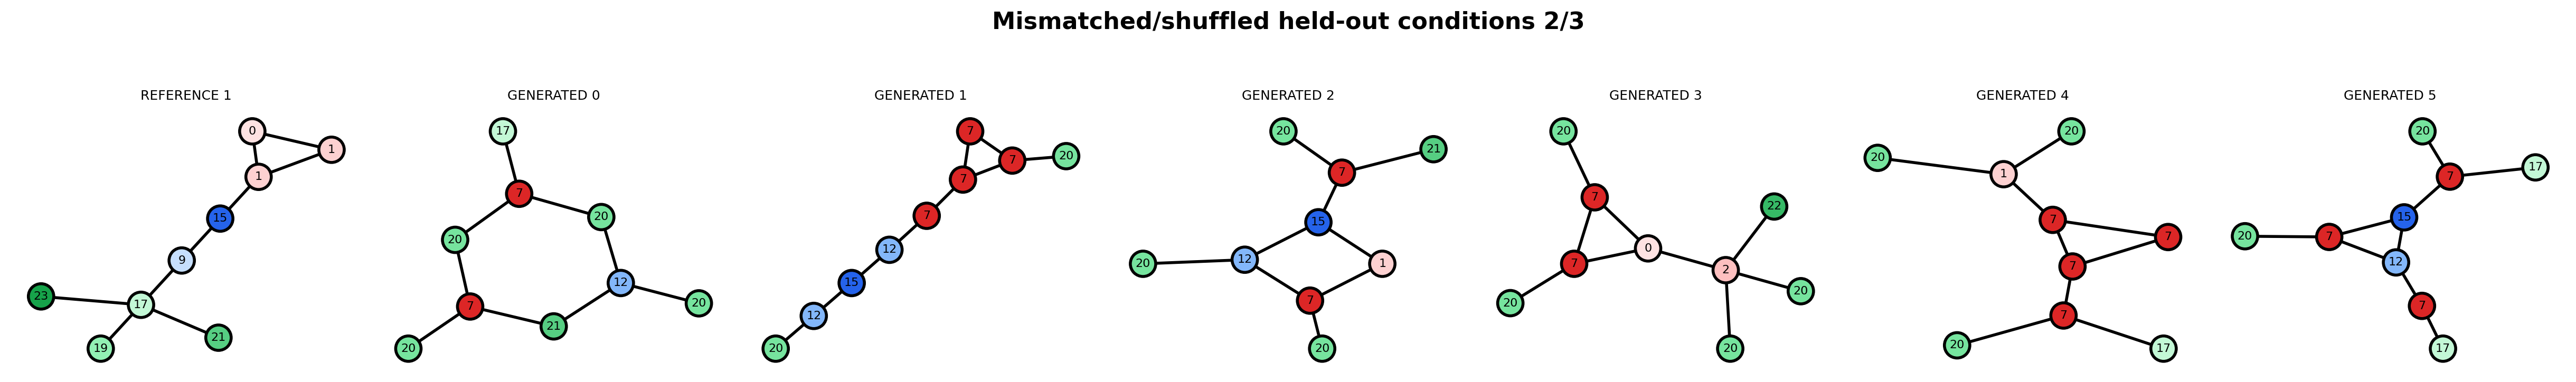

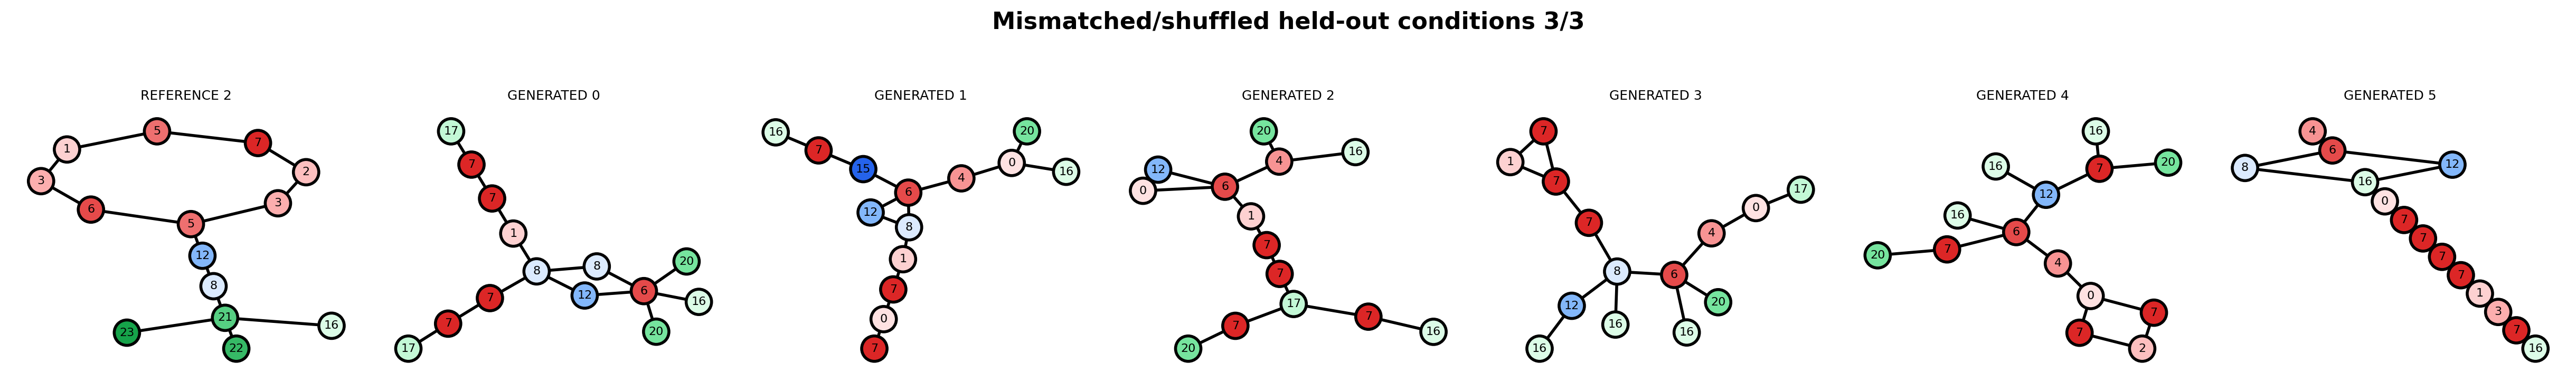

In [6]:
plot_overfit_summary(overfit_evaluation)
plot_overfit_reconstructions(
    plot_artificial_graphs,
    overfit_evaluation,
    fit_graphs,
    heldout_graphs,
    n_candidates=6,
)